# Clustering Algorithms

Here we go through some examples of various clustering algorithms including code for creating and visualizing the clustering output.  The algorithms covered are:

* K-Means
* Hierarchical Clustering
* Density-based Clustering (DBSCAN)

## K-Means Clustering

One of the simplest clustering algorithms is **K-Means**.  The basic idea is to create *k* groups and segment our data into these groups based on their similarity.  Despite its simplicity, K-Means is extremely useful since it is computationally cheap and is an unsupervised algorithms that can allow for rapid discovery of insights from unlabeled data.

In the example code here we'll use the scikit-learn library and its functions to build and test the model.  The particular example we use to illustrate is a customer segmentation application.

First, import the libraries we want.

In [1]:
import random
import numpy as np
import scipy
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

### Randomly Generated Data

To test out some of the features in the K-Means functions of scikit-learn we'll generate some random data and use the k-Mean clustering algorithm on it.  We'll also illustrate some features of the algorithm itself.

The idea here is that we create some random clusters of points (using the **make_blobs** class) and then test how well the K-Means algorithm can identify the blobs.

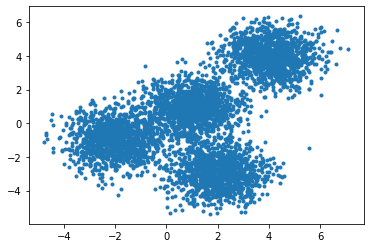

In [2]:
X,y = make_blobs(n_samples = 5000, centers = [[4,4], [-2,-1], [2,-3], [1,1]], cluster_std = 0.9) # Make 4 blobs of data with 5000 points total

plt.scatter(X[:,0], X[:,1], marker='.') # Visualize scatterplot of the randomized blobs

Now we build the K-Means model.  There are a number of options in the scikit-learn library for this.  The important paramters we'll specify are:

* init: Initialization method. We use "k-means++" which will select the initial cluster points intelligently to help minimize convergence time.
* n_clusters: Number of clusters we should form (and number of centroids we should generate).  We know going in that we want this value equal to 4.  In real world cases we might need to play with this number depending on the dataset.
* n_init: Number of times to run the K-Means algorithm with different initial centroid locations.  K-Means can get trapped in local maxima or minima, so resetting with different initial conditions can help alleviate this problem and is more likely to uncover global extrema.

In [3]:
# Build the model

k_means = KMeans(init='k-means++', n_clusters = 4, n_init = 12)

In [4]:
# Fit the model to our data

k_means.fit(X)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=4, n_init=12, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

In [5]:
# Save the labels for each point

k_means_labels = k_means.labels_
k_means_labels

array([3, 1, 2, ..., 1, 3, 1], dtype=int32)

In [6]:
# Save the cluster centers

k_means_cluster_centers = k_means.cluster_centers_
k_means_cluster_centers

array([[ 1.00952402,  0.96200193],
       [-2.0093009 , -0.97126704],
       [ 2.03101977, -2.96352544],
       [ 4.04149941,  3.99079663]])

### Visualizing K-Means on Random Data

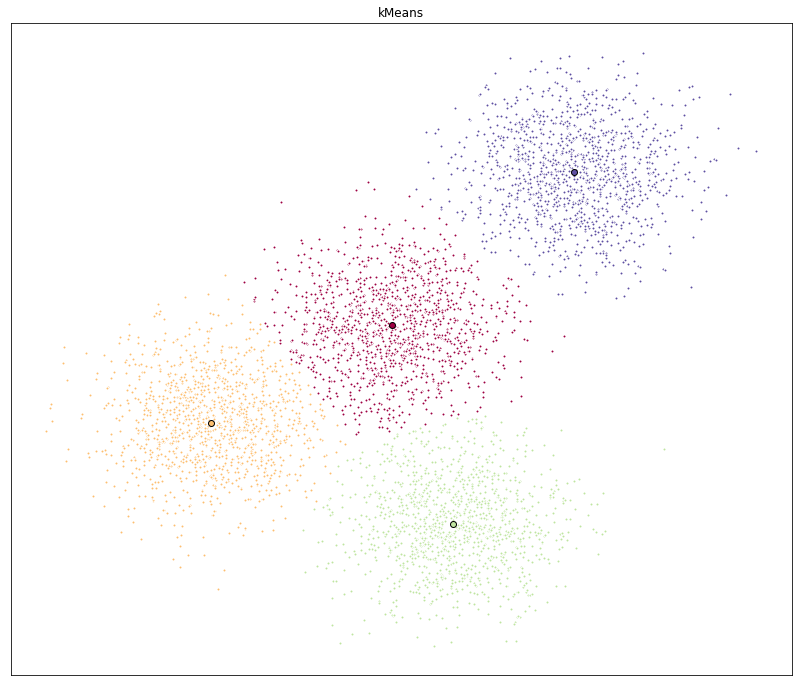

In [7]:
# Initialize the plot

fig = plt.figure(figsize = (14,12))

# We use a color map that will produce an array of colors based on the number of labels

colors = plt.cm.Spectral(np.linspace(0,1,len(set(k_means_labels))))

# Create the plot

ax = fig.add_subplot(1,1,1)

# Plot the data points and the centroids

for k, col in zip(range(len([[4,4],[-2,-1],[2,-3],[1,1]])), colors):
    # Create a list of all data points with the data points in the cluster are labeled true, else false
    my_members = (k_means_labels == k)
    
    # Define the cluster centers
    cluster_center = k_means_cluster_centers[k]
    
    # Plot the datapoints
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.')
    
    # Plot the cluster centers
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col, markeredgecolor='k', markersize=6)

# Formatting
ax.set_title('kMeans')
ax.set_xticks(())
ax.set_yticks(())
plt.show()

### Customer Segementation Example with K-Means Clustering

Here we use a sample customer dataset to show a use-case of K-Means clustering for customer segmentation.

First, we import pandas and load the dataset into a frame and then apply some standard preprocessing to clean up the dataset and normalize the data for use in clustering.

In [8]:
import pandas as pd
cust_df = pd.read_csv("Cust_Segmentation.csv")
cust_df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


In [9]:
# Some preprocessing of the data to get it into formats we like

df = cust_df.drop('Address', axis = 1)
df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,6.3
1,2,47,1,26,100,4.582,8.218,0.0,12.8
2,3,33,2,10,57,6.111,5.802,1.0,20.9
3,4,29,2,4,19,0.681,0.516,0.0,6.3
4,5,47,1,31,253,9.308,8.908,0.0,7.2


In [10]:
# Normalize the dataset

from sklearn.preprocessing import StandardScaler
X = df.values[:,1:]
X = np.nan_to_num(X)
Clus_dataSet = StandardScaler().fit_transform(X)
Clus_dataSet

array([[ 0.74291541,  0.31212243, -0.37878978, ..., -0.59048916,
        -0.52379654, -0.57652509],
       [ 1.48949049, -0.76634938,  2.5737211 , ...,  1.51296181,
        -0.52379654,  0.39138677],
       [-0.25251804,  0.31212243,  0.2117124 , ...,  0.80170393,
         1.90913822,  1.59755385],
       ...,
       [-1.24795149,  2.46906604, -1.26454304, ...,  0.03863257,
         1.90913822,  3.45892281],
       [-0.37694723, -0.76634938,  0.50696349, ..., -0.70147601,
        -0.52379654, -1.08281745],
       [ 2.1116364 , -0.76634938,  1.09746566, ...,  0.16463355,
        -0.52379654, -0.2340332 ]])

### Modeling the data

Now we create the model and derive some insights.

In [11]:
clusterNum = 3
k_means = KMeans(init = "k-means++", n_clusters = clusterNum, n_init = 12)
k_means.fit(X)
labels = k_means.labels_

df["Clus_km"] = labels

df.groupby('Clus_km').mean()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Clus_km,,,,,,,,,
0,432.468413,32.964561,1.614792,6.374422,31.164869,1.032541,2.104133,0.285185,10.094761
1,410.166667,45.388889,2.666667,19.555556,227.166667,5.678444,10.907167,0.285714,7.322222
2,402.295082,41.333333,1.956284,15.256831,83.928962,3.103639,5.765279,0.171233,10.724590


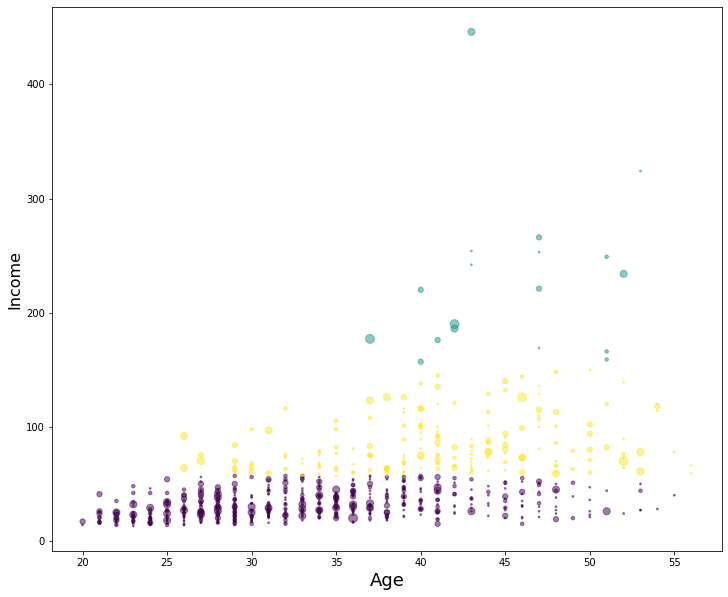

In [12]:
area = np.pi * ( X[:, 1])**2
plt.figure(figsize = (12,10))
plt.scatter(X[:,0], X[:, 3], s = area, c = labels.astype(np.float), alpha = 0.5)
plt.xlabel('Age', fontsize = 18)
plt.ylabel('Income', fontsize = 16)
plt.show()

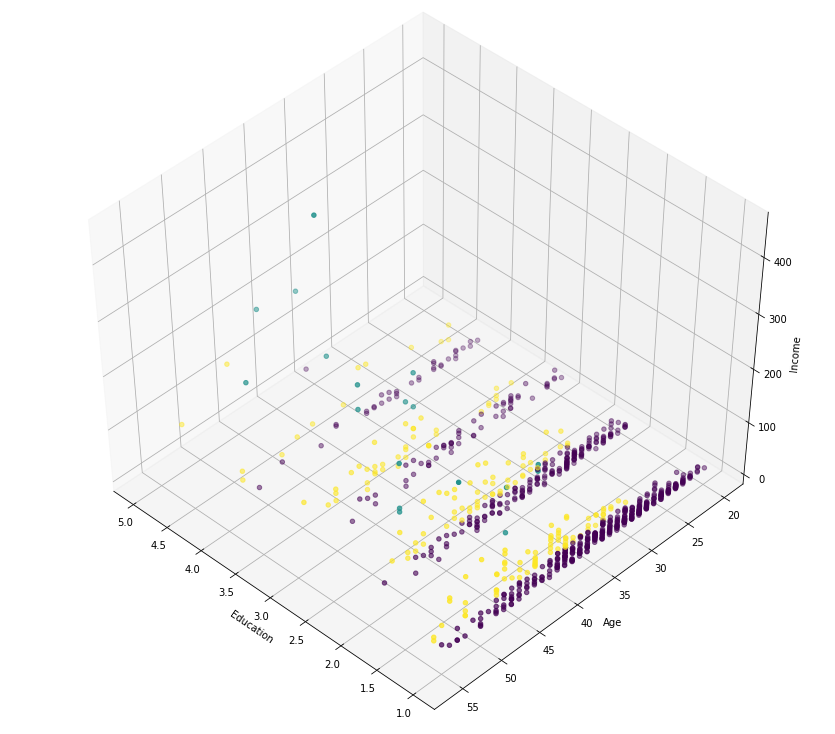

In [13]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(1, figsize = (12,10))
plt.clf()
ax = Axes3D(fig, rect = [0,0,.95,1], elev = 48, azim = 134)

plt.cla()
ax.set_xlabel('Education')
ax.set_ylabel('Age')
ax.set_zlabel('Income')

ax.scatter(X[:,1], X[:,0],X[:,3], c = labels.astype(np.float))

## Hierarchical Clustering

The second clustering algorithm we look at is hierarchical clustering. Again, we use scikit-learn for the clustering algorithm, we also do a bit of work to visualize the clustering, creating a dendogram for visualization.  We follow the same pattern as with the K-Means example: we first generate and run the algorithm on random data, then illustrate with a sample dataset (this time on vehicle specifications).

### Random Data

First, load a few extra libraries that we want and then generate the random data and take a look at a scatter plot.

In [14]:
from scipy import ndimage
from scipy.cluster import hierarchy
from scipy.spatial import distance_matrix
from sklearn import manifold, datasets
from sklearn.cluster import AgglomerativeClustering

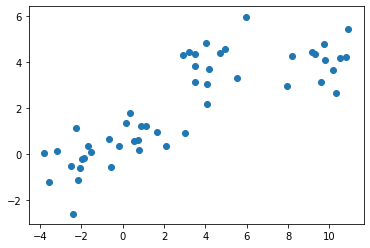

In [15]:
X1, y1 = make_blobs(n_samples = 50, centers = [[4,4],[-2,-1],[1,1],[10,4]], cluster_std = 0.9)

plt.scatter(X1[:,0], X1[:,1], marker = 'o')

Now we want to create clusters from this random data. The class we are using from scikit-learn requires us to specify:
* n_clusters: the number of clusters we want to form. We choose to form 4 clusters.
* linkage: This specifies the linkage criterion to use, i.e., what distance metric to use to form the links to cause clusters to agglomerate. We use 'complete' in this case.

In [16]:
# Apply the clustering algorithm and save the result

agglom = AgglomerativeClustering(n_clusters = 4, linkage = 'complete')
agglom.fit(X1, y1)

AgglomerativeClustering(affinity='euclidean', compute_full_tree='auto',
                        connectivity=None, distance_threshold=None,
                        linkage='complete', memory=None, n_clusters=4)

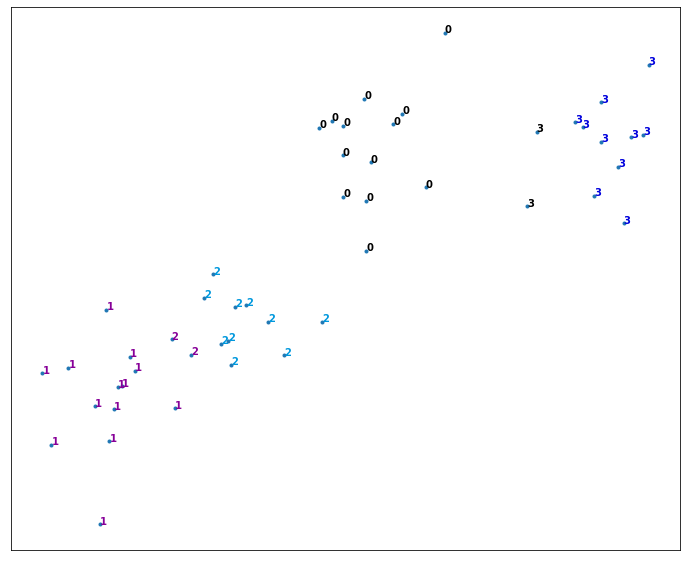

In [17]:
# Create a plot

plt.figure(figsize = (12,10))

x_min, x_max = np.min(X1, axis = 0), np.max(X1, axis = 0)

X1 = (X1 - x_min) / (x_max - x_min)

for i in range(X1.shape[0]):
    plt.text(X1[i,0], X1[i,1], str(y1[i]),
            color = plt.cm.nipy_spectral(agglom.labels_[i] / 10.),
            fontdict = {'weight': 'bold', 'size': 10})

plt.xticks([])
plt.yticks([])

plt.scatter(X1[:,0], X1[:,1], marker = '.')
plt.show()

### Dendogram Visualization of Hierarchical Clustering

In [18]:
# Display the distance matrix indicating the distances between pairs of points in our data

dist_matrix = distance_matrix(X1,X1)
print(dist_matrix)

[[0.         0.44670005 0.68803581 ... 0.63875016 0.53521672 0.48297189]
 [0.44670005 0.         0.97109462 ... 0.88793423 0.17455542 0.67996702]
 [0.68803581 0.97109462 0.         ... 0.1005983  1.12662476 0.30173824]
 ...
 [0.63875016 0.88793423 0.1005983  ... 0.         1.04789446 0.20991029]
 [0.53521672 0.17455542 1.12662476 ... 1.04789446 0.         0.84276926]
 [0.48297189 0.67996702 0.30173824 ... 0.20991029 0.84276926 0.        ]]


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  """Entry point for launching an IPython kernel.


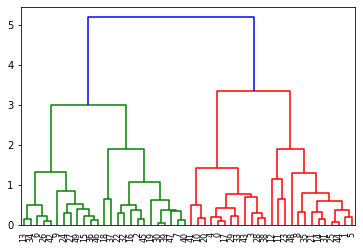

In [19]:
Z = hierarchy.linkage(dist_matrix, 'complete')

dendro = hierarchy.dendrogram(Z)

### Hierarchical Clustering on Vehicle Dataset

Now we use some non-random data to illustrate the hierarchical clustering algorithm.  The dataset we use is to predict what group of vehicles new prototype vehicles fall into.  So, we are trying to create clusters of vehicles using various dimensions in the data, and then place new vehicles into the most appropriate cluster.

In [20]:
# Load the data into a pandas dataframe and take a look at it

pdf = pd.read_csv('cars_clus.csv')
print("Shape of dataset: ", pdf.shape)

pdf.head(5)

Shape of dataset:  (159, 16)


,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.000,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2.828,0.0
1,Acura,TL,39.384,19.875,0.000,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,3.673,0.0
2,Acura,CL,14.114,18.225,0.000,$null$,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2.647,0.0
3,Acura,RL,8.588,29.725,0.000,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2.150,0.0
4,Audi,A4,20.397,22.255,0.000,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,3.015,0.0


In [21]:
# Some data cleaning and preprocessing

pdf[['sales','resale','type','price','engine_s','horsepow','wheelbas','width','length','curb_wgt','fuel_cap','mpg','lnsales']] = pdf[['sales','resale','type','price','engine_s','horsepow','wheelbas','width','length','curb_wgt','fuel_cap','mpg','lnsales']].apply(pd.to_numeric, errors = 'coerce')
pdf = pdf.dropna()
pdf = pdf.reset_index(drop = True)
print("Shape of dataset after cleaning: ", pdf.size)
pdf.head(5)

Shape of dataset after cleaning:  1872


,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.0,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2.828,0.0
1,Acura,TL,39.384,19.875,0.0,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,3.673,0.0
2,Acura,RL,8.588,29.725,0.0,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2.150,0.0
3,Audi,A4,20.397,22.255,0.0,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,3.015,0.0
4,Audi,A6,18.780,23.555,0.0,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,2.933,0.0


In [22]:
# Select the features we want to use

featureset = pdf[['engine_s','horsepow','wheelbas','width','length','curb_wgt','fuel_cap','mpg']]

In [23]:
# Normalize the data

from sklearn.preprocessing import MinMaxScaler

x = featureset.values
min_max_scaler = MinMaxScaler()
feature_mtx = min_max_scaler.fit_transform(x)
feature_mtx [0:5]

array([[0.11428571, 0.21518987, 0.18655098, 0.28143713, 0.30625832,
        0.2310559 , 0.13364055, 0.43333333],
       [0.31428571, 0.43037975, 0.3362256 , 0.46107784, 0.5792277 ,
        0.50372671, 0.31797235, 0.33333333],
       [0.35714286, 0.39240506, 0.47722343, 0.52694611, 0.62849534,
        0.60714286, 0.35483871, 0.23333333],
       [0.11428571, 0.24050633, 0.21691974, 0.33532934, 0.38082557,
        0.34254658, 0.28110599, 0.4       ],
       [0.25714286, 0.36708861, 0.34924078, 0.80838323, 0.56724368,
        0.5173913 , 0.37788018, 0.23333333]])

### Using numpy and Scipy to cluster the Vehicle Data

In [24]:
# Calculating the distance matrix for the data we want to cluster

leng = feature_mtx.shape[0]
D = np.zeros([leng,leng])
for i in range(leng):
    for j in range(leng):
        D[i,j] = scipy.spatial.distance.euclidean(feature_mtx[i], feature_mtx[j])

In [25]:
Z = hierarchy.linkage(D, 'complete')

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  """Entry point for launching an IPython kernel.


In [26]:
from scipy.cluster.hierarchy import fcluster
import pylab

max_d = 3
clusters = fcluster(Z, max_d, criterion = 'distance')
clusters

array([ 1,  5,  5,  6,  5,  4,  6,  5,  5,  5,  5,  5,  4,  4,  5,  1,  6,
        5,  5,  5,  4,  2, 11,  6,  6,  5,  6,  5,  1,  6,  6, 10,  9,  8,
        9,  3,  5,  1,  7,  6,  5,  3,  5,  3,  8,  7,  9,  2,  6,  6,  5,
        4,  2,  1,  6,  5,  2,  7,  5,  5,  5,  4,  4,  3,  2,  6,  6,  5,
        7,  4,  7,  6,  6,  5,  3,  5,  5,  6,  5,  4,  4,  1,  6,  5,  5,
        5,  6,  4,  5,  4,  1,  6,  5,  6,  6,  5,  5,  5,  7,  7,  7,  2,
        2,  1,  2,  6,  5,  1,  1,  1,  7,  8,  1,  1,  6,  1,  1],
      dtype=int32)

In [27]:
k = 5
clusters = fcluster(Z, k, criterion = 'maxclust')
clusters

array([1, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 2, 3, 1, 3, 3, 3, 3, 2, 1,
       5, 3, 3, 3, 3, 3, 1, 3, 3, 4, 4, 4, 4, 2, 3, 1, 3, 3, 3, 2, 3, 2,
       4, 3, 4, 1, 3, 3, 3, 2, 1, 1, 3, 3, 1, 3, 3, 3, 3, 2, 2, 2, 1, 3,
       3, 3, 3, 2, 3, 3, 3, 3, 2, 3, 3, 3, 3, 2, 2, 1, 3, 3, 3, 3, 3, 2,
       3, 2, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 3, 3, 1, 1, 1,
       3, 4, 1, 1, 3, 1, 1], dtype=int32)

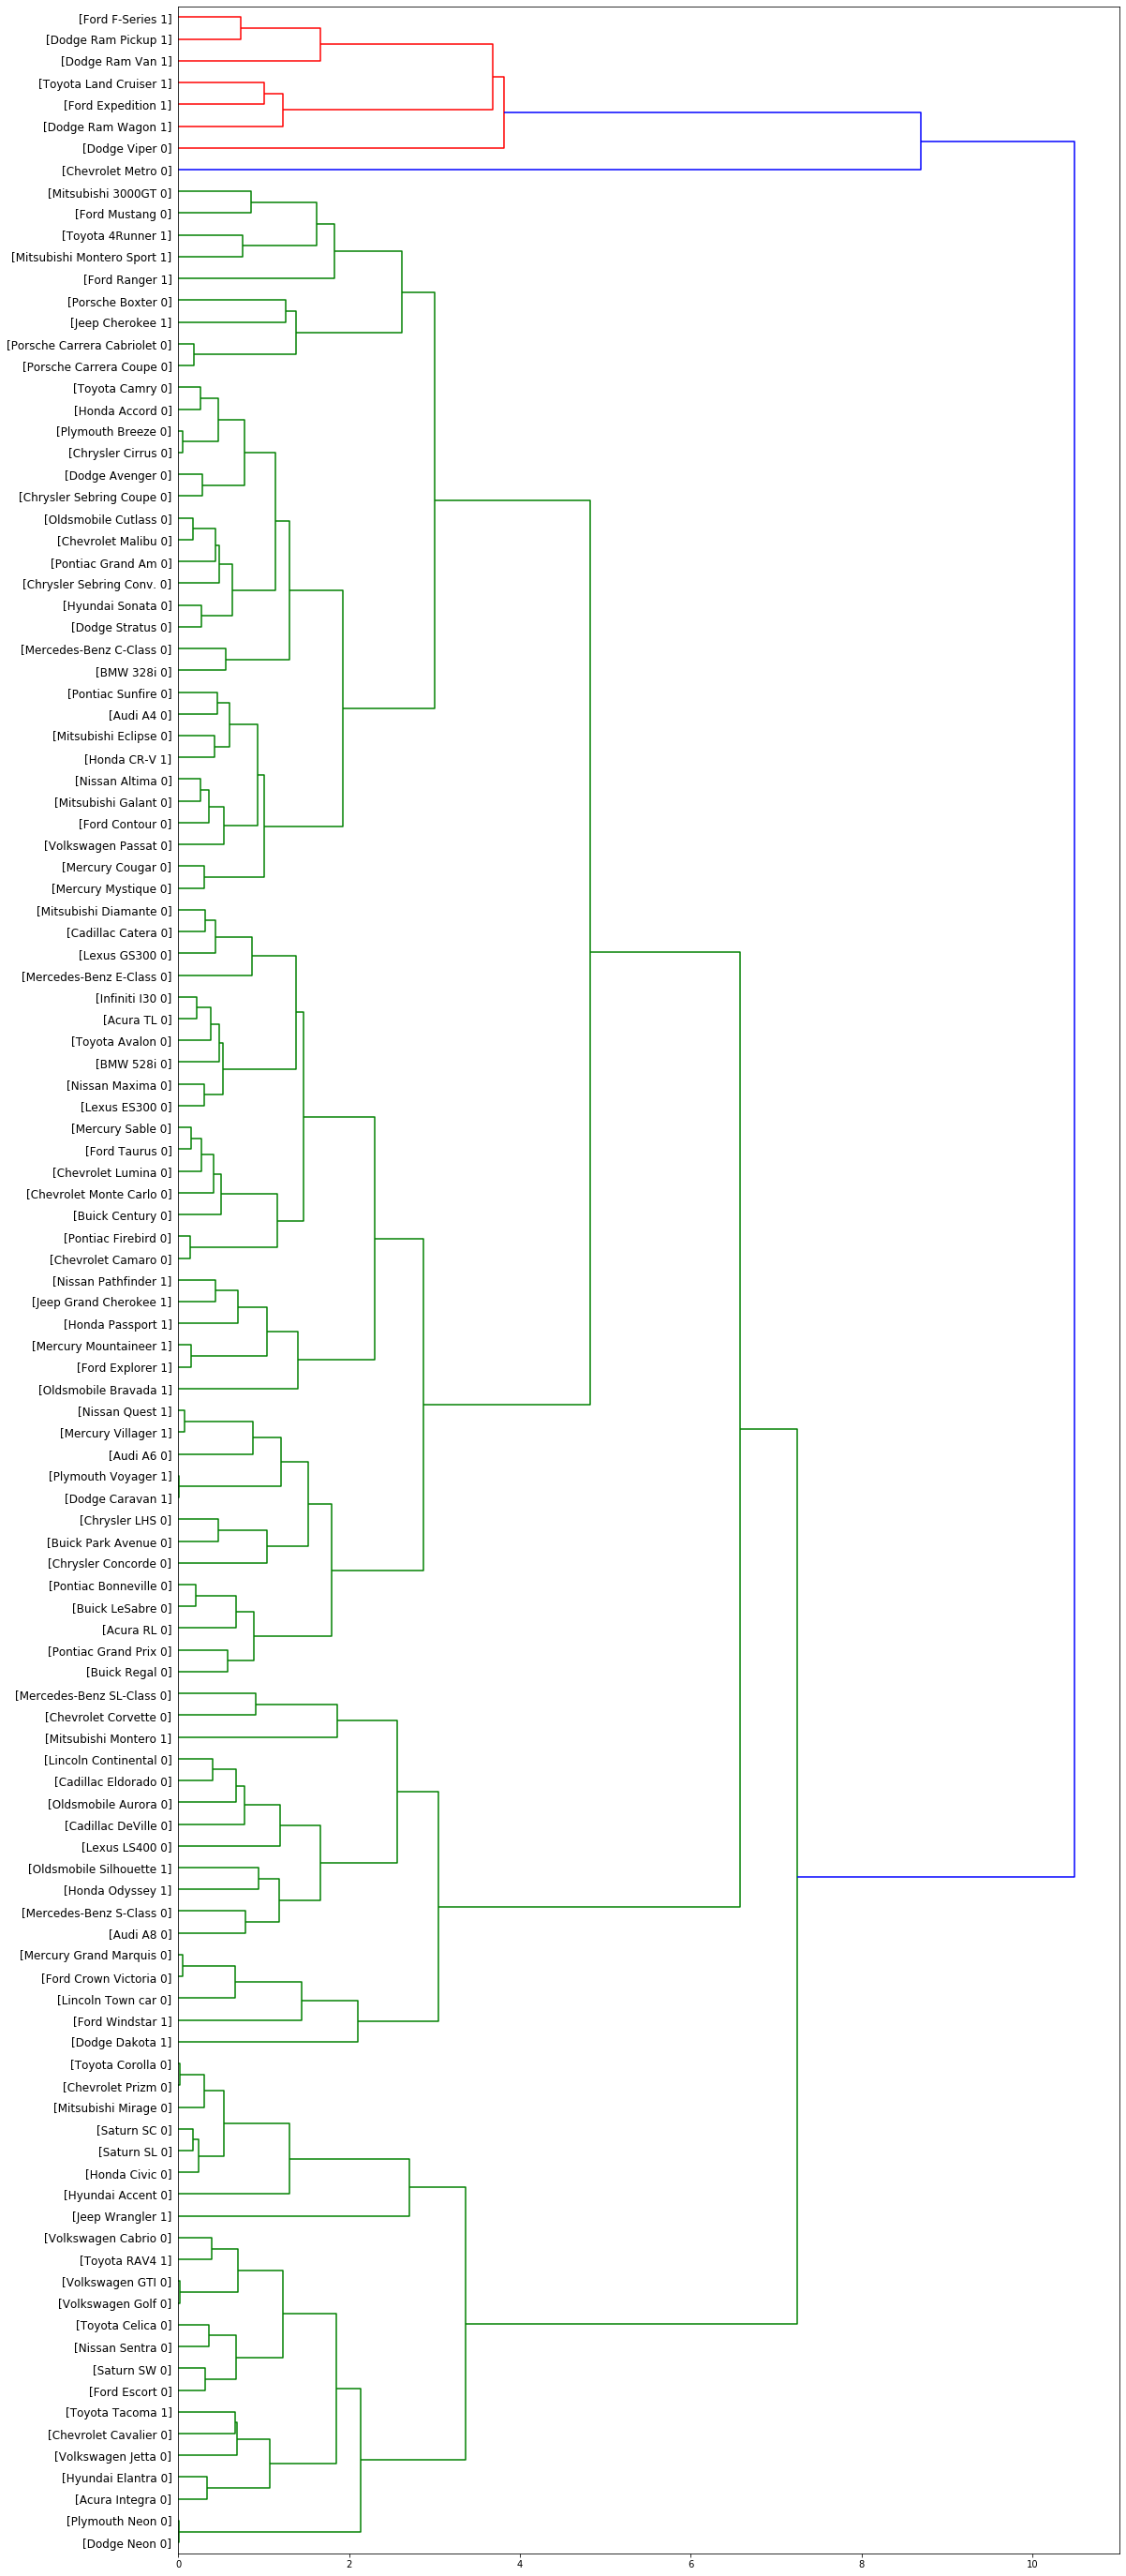

In [28]:
fig = pylab.figure(figsize=(18,50))
def llf(id):
    return'[%s %s %s]' % (pdf['manufact'][id], pdf['model'][id], int(float(pdf['type'][id])))

dendro = hierarchy.dendrogram(Z, leaf_label_func = llf, leaf_rotation = 0, leaf_font_size = 12, orientation = 'right')

So, that is one way to visualize the data.  For this particular dataset, that visualization is a bit unwieldy.  Using scikit-laern we can try another approach to forming and visualizing the clusters.  We illustrate this alternative next.

### Alternative Visualization Using scikit-learn

In [29]:
dist_matrix = distance_matrix(feature_mtx, feature_mtx)
print(dist_matrix)

[[0.         0.57777143 0.75455727 ... 0.28530295 0.24917241 0.18879995]
 [0.57777143 0.         0.22798938 ... 0.36087756 0.66346677 0.62201282]
 [0.75455727 0.22798938 0.         ... 0.51727787 0.81786095 0.77930119]
 ...
 [0.28530295 0.36087756 0.51727787 ... 0.         0.41797928 0.35720492]
 [0.24917241 0.66346677 0.81786095 ... 0.41797928 0.         0.15212198]
 [0.18879995 0.62201282 0.77930119 ... 0.35720492 0.15212198 0.        ]]


In [30]:
agglom = AgglomerativeClustering(n_clusters = 6, linkage = 'complete')
agglom.fit(feature_mtx)
agglom.labels_

array([1, 2, 2, 1, 2, 3, 1, 2, 2, 2, 2, 2, 3, 3, 2, 1, 1, 2, 2, 2, 5, 1,
       4, 1, 1, 2, 1, 2, 1, 1, 1, 5, 0, 0, 0, 3, 2, 1, 2, 1, 2, 3, 2, 3,
       0, 3, 0, 1, 1, 1, 2, 3, 1, 1, 1, 2, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1,
       1, 2, 1, 2, 2, 1, 1, 2, 3, 2, 3, 1, 2, 3, 5, 1, 1, 2, 3, 2, 1, 3,
       2, 3, 1, 1, 2, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       2, 0, 1, 1, 1, 1, 1])

In [31]:
pdf['cluster_'] = agglom.labels_
pdf.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition,cluster_
0,Acura,Integra,16.919,16.360,0.0,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2.828,0.0,1
1,Acura,TL,39.384,19.875,0.0,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,3.673,0.0,2
2,Acura,RL,8.588,29.725,0.0,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2.150,0.0,2
3,Audi,A4,20.397,22.255,0.0,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,3.015,0.0,1
4,Audi,A6,18.780,23.555,0.0,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,2.933,0.0,2


'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches

Text(0, 0.5, 'mpg')

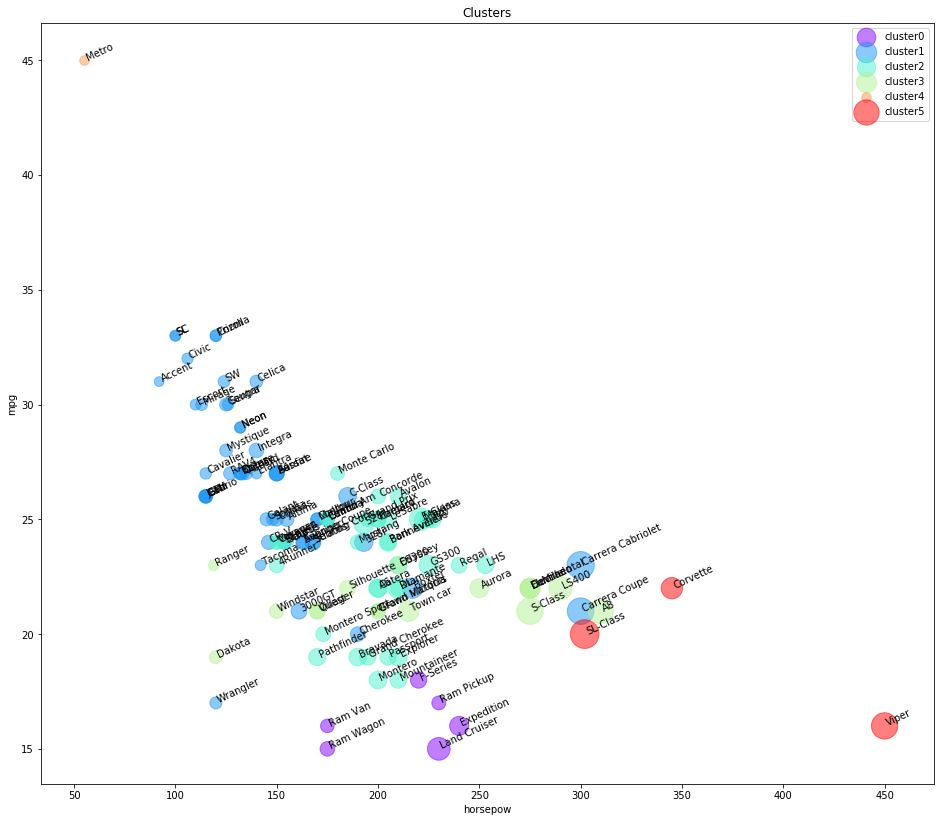

In [32]:
import matplotlib.cm as cm
n_clusters = max(agglom.labels_)+1
colors = cm.rainbow(np.linspace(0,1,n_clusters))
cluster_labels = list(range(0,n_clusters))

# Create a figure
plt.figure(figsize = (16,14))

for color, label in zip(colors, cluster_labels):
    subset = pdf[pdf.cluster_ == label]
    for i in subset.index:
        plt.text(subset.horsepow[i], subset.mpg[i], str(subset['model'][i]), rotation = 25)
    plt.scatter(subset.horsepow, subset.mpg, s = subset.price * 10, c = color, label = 'cluster' + str(label), alpha = 0.5)
plt.legend()
plt.title('Clusters')
plt.xlabel('horsepow')
plt.ylabel('mpg')

This shows us a scatter plot of each cluster.  Unfortunately, in this scatter plot it is rather difficult to figure out where the centroid of each cluster is.  Also, the truck v. car distinction is not readily apparant from the scatterplot.  

We apply a few additional measures to try to improve the visualization.

In [33]:
pdf.groupby(['cluster_','type'])['cluster_'].count()

cluster_  type
0         1.0      6
1         0.0     47
          1.0      5
2         0.0     27
          1.0     11
3         0.0     10
          1.0      7
4         0.0      1
5         0.0      3
Name: cluster_, dtype: int64

In [34]:
agg_cars = pdf.groupby(['cluster_','type'])['horsepow', 'engine_s', 'mpg', 'price'].mean()
agg_cars

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  """Entry point for launching an IPython kernel.


horsepow  engine_s        mpg      price
cluster_ type                                            
0        1.0   211.666667  4.483333  16.166667  29.024667
1        0.0   146.531915  2.246809  27.021277  20.306128
         1.0   145.000000  2.580000  22.200000  17.009200
2        0.0   203.111111  3.303704  24.214815  27.750593
         1.0   182.090909  3.345455  20.181818  26.265364
3        0.0   256.500000  4.410000  21.500000  42.870400
         1.0   160.571429  3.071429  21.428571  21.527714
4        0.0    55.000000  1.000000  45.000000   9.235000
5        0.0   365.666667  6.233333  19.333333  66.010000

'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches

Text(0, 0.5, 'mpg')

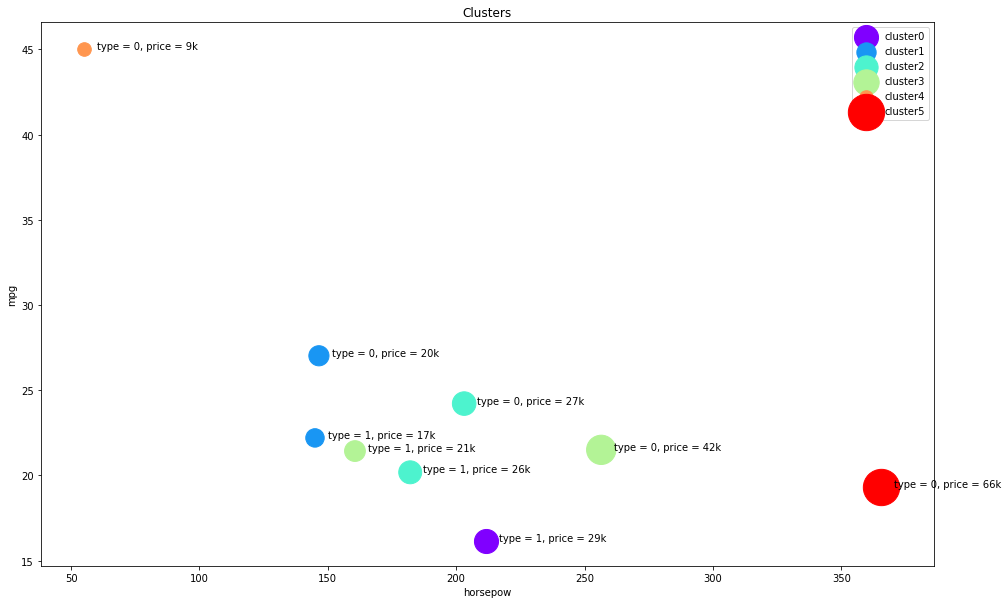

In [35]:
plt.figure(figsize = (16,10))
for color, label in zip(colors, cluster_labels):
    subset = agg_cars.loc[(label,),]
    for i in subset.index:
        plt.text(subset.loc[i][0]+5, subset.loc[i][2], 'type = ' + str(int(i)) + ', price = ' + str(int(subset.loc[i][3]))+'k')
    plt.scatter(subset.horsepow, subset.mpg, s = subset.price * 20, c = color, label = 'cluster' + str(label))
plt.legend()
plt.title('Clusters')
plt.xlabel('horsepow')
plt.ylabel('mpg')

## DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

The DBSCAN algorithm is a clustering algorithm that has some advantage over k-Means and other clustering algorithms.  The two main advantages are

* Ability to deal with arbitrary cluster shapes
* Ability to deal with outliers more robustly

The DBSCAN algorithm is an unsupervised clustering algorithm and tries to identify clusters based on the density of data in the region.  By using this approach it can identify arbitrarily shaped clusters (whereas an algorithm like k-Means is identifying spheres).  Further, since it is looking for regions of density, it is better able to ignore outlier points.  These outlier points are difficult for other algorithms such as k-Means to identify.

For our implementation of DBSCAN, we'll use **numpy**, **scikit-learn**, **make_blobs** for random data generation, scikit-learn's preprocessing functions, and **matplotlib.pyplot**

In [36]:
# This package is for visualization of map data

import os 
os.environ["PROJ_LIB"] = r'/opt/anaconda3/share/proj/'
from mpl_toolkits.basemap import Basemap

In [37]:
import csv
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline

In [38]:
# Generate random blobs of data to play with

def createDataPoints(centroidLocation, numSamples, clusterDeviation):
    X, y = make_blobs(n_samples = numSamples, centers = centroidLocation, cluster_std = clusterDeviation)
    
    X = StandardScaler().fit_transform(X)
    return X, y

X, y = createDataPoints([[4,3],[2,-1],[-1,4]], 1500, 0.5)

### Modeling the (random) data

There are two main parameters involved in the DBSCAN algorithm: epsilon and minimum points.  **Epsilon** determins the radius over which we determine density of points.  **minimumSamples** determines the minimum number of points we must have in a neighborhood to define a cluster.

Next we specify parameters and build the model

In [39]:
epsilon = 0.3
minimumSamples = 7
db = DBSCAN(eps = epsilon, min_samples = minimumSamples).fit(X)
labels = db.labels_
labels

array([0, 1, 1, ..., 1, 0, 0])

In [40]:
# Identify outliers, marking points in a cluster with True and outliers with False

core_samples_mask = np.zeros_like(db.labels_, dtype = bool)
core_samples_mask[db.core_sample_indices_] = True
core_samples_mask

array([ True,  True,  True, ...,  True,  True,  True])

In [41]:
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_clusters_

3

In [42]:
unique_labels = set(labels)
unique_labels

{-1, 0, 1, 2}

### Data Visualization

In [43]:
colors = plt.cm.Spectral(np.linspace(0,1,len(unique_labels)))

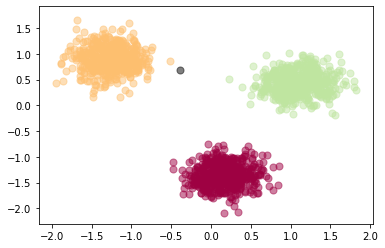

In [44]:
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'k'
    
    class_member_mask = (labels == k)
    
    xy = X[class_member_mask & core_samples_mask]
    plt.scatter(xy[:,0], xy[:,1], s = 50, c = [col], marker = u'o', alpha = 0.5)
    
    xy = X[class_member_mask & ~core_samples_mask]
    plt.scatter(xy[:,0], xy[:,1], s = 50, c = [col], marker = u'o', alpha = 0.5)

### Using DBSCAN on Weather Station Clustering Data

One of the strengths of the DBSCAN algorithm is its use on spatial data. This strength derives from its ability to identify arbitrary shaped clusters while ignoring outliers.  The following example uses the DBSCAN data to group the weather stations in Canada by location.

First, we load the dataset and perform some standard cleaning and preprocessing.

In [68]:
# Import the data and read it into a pandas dataframe

filename = 'weather-stations.csv'
pdf = pd.read_csv(filename)
pdf.head(5)

,Stn_Name,Lat,Long,Prov,Tm,DwTm,D,Tx,DwTx,Tn,...,DwP,P%N,S_G,Pd,BS,DwBS,BS%,HDD,CDD,Stn_No
0,CHEMAINUS,48.935,-123.742,BC,8.2,0.0,NaN,13.5,0.0,1.0,...,0.0,NaN,0.0,12.0,NaN,NaN,NaN,273.3,0.0,1011500
1,COWICHAN LAKE FORESTRY,48.824,-124.133,BC,7.0,0.0,3.0,15.0,0.0,-3.0,...,0.0,104.0,0.0,12.0,NaN,NaN,NaN,307.0,0.0,1012040
2,LAKE COWICHAN,48.829,-124.052,BC,6.8,13.0,2.8,16.0,9.0,-2.5,...,9.0,NaN,NaN,11.0,NaN,NaN,NaN,168.1,0.0,1012055
3,DISCOVERY ISLAND,48.425,-123.226,BC,NaN,NaN,NaN,12.5,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1012475
4,DUNCAN KELVIN CREEK,48.735,-123.728,BC,7.7,2.0,3.4,14.5,2.0,-1.0,...,2.0,NaN,NaN,11.0,NaN,NaN,NaN,267.7,0.0,1012573


In [69]:
# Remove rows that don't have value in the Tm field

pdf = pdf[pd.notnull(pdf["Tm"])]
pdf = pdf.reset_index(drop = True)
pdf.head(5)

,Stn_Name,Lat,Long,Prov,Tm,DwTm,D,Tx,DwTx,Tn,...,DwP,P%N,S_G,Pd,BS,DwBS,BS%,HDD,CDD,Stn_No
0,CHEMAINUS,48.935,-123.742,BC,8.2,0.0,NaN,13.5,0.0,1.0,...,0.0,NaN,0.0,12.0,NaN,NaN,NaN,273.3,0.0,1011500
1,COWICHAN LAKE FORESTRY,48.824,-124.133,BC,7.0,0.0,3.0,15.0,0.0,-3.0,...,0.0,104.0,0.0,12.0,NaN,NaN,NaN,307.0,0.0,1012040
2,LAKE COWICHAN,48.829,-124.052,BC,6.8,13.0,2.8,16.0,9.0,-2.5,...,9.0,NaN,NaN,11.0,NaN,NaN,NaN,168.1,0.0,1012055
3,DUNCAN KELVIN CREEK,48.735,-123.728,BC,7.7,2.0,3.4,14.5,2.0,-1.0,...,2.0,NaN,NaN,11.0,NaN,NaN,NaN,267.7,0.0,1012573
4,ESQUIMALT HARBOUR,48.432,-123.439,BC,8.8,0.0,NaN,13.1,0.0,1.9,...,8.0,NaN,NaN,12.0,NaN,NaN,NaN,258.6,0.0,1012710


### Visualization

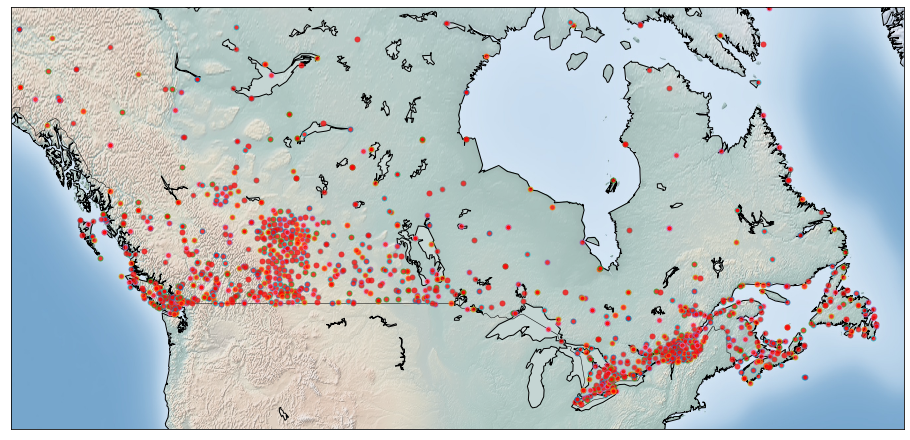

In [71]:
from mpl_toolkits.basemap import Basemap
from pylab import rcParams

rcParams['figure.figsize'] = (16,12)
llon = -140
ulon = -50
llat = 40
ulat = 65

pdf = pdf[(pdf['Long'] > llon) & (pdf['Long'] < ulon) & (pdf['Lat'] > llat) & (pdf['Lat'] < ulat)]

my_map = Basemap(projection = 'merc', resolution = 'l', area_thresh = 1000.0, llcrnrlon = llon, llcrnrlat = llat, urcrnrlon = ulon, urcrnrlat = ulat)

my_map.drawcoastlines()
my_map.drawcountries()
my_map.fillcontinents(color = 'white', alpha = 0.3)
my_map.shadedrelief()

xs, ys = my_map(np.asarray(pdf.Long), np.asarray(pdf.Lat))
pdf['xm'] = xs.tolist()
pdf['ym'] = ys.tolist()

for index, row in pdf.iterrows():
    my_map.plot(row.xm, row.ym, markerfacecolor = ([1,0,0]), marker = 'o', markersize = 5, alpha = 0.75)
plt.show()

### Clustering by Location (Latitude & Longitude)

First, we use DBSCAN to cluster these stations from a distance matrix that we derive from the latitude and longitude of the weather stations.

In [72]:
from sklearn.cluster import DBSCAN
import sklearn.utils
from sklearn.preprocessing import StandardScaler
sklearn.utils.check_random_state(1000)

Clus_dataSet = pdf[['xm','ym']]
Clus_dataSet = np.nan_to_num(Clus_dataSet)
Clus_dataSet = StandardScaler().fit_transform(Clus_dataSet)

db = DBSCAN(eps = 0.15, min_samples = 10).fit(Clus_dataSet)
core_samples_mask = np.zeros_like(db.labels_, dtype = bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_
pdf["Clus_Db"] = labels

realClusterNum = len(set(labels)) - (1 if -1 in labels else 0)
clusterNum = len(set(labels))

pdf[["Stn_Name", "Tx", "Tm", "Clus_Db"]].head(5)

,Stn_Name,Tx,Tm,Clus_Db
0,CHEMAINUS,13.5,8.2,0
1,COWICHAN LAKE FORESTRY,15.0,7.0,0
2,LAKE COWICHAN,16.0,6.8,0
3,DUNCAN KELVIN CREEK,14.5,7.7,0
4,ESQUIMALT HARBOUR,13.1,8.8,0


In [73]:
set(labels)

{-1, 0, 1, 2, 3, 4}

Cluster 0, Avg Temp: 6.2211920529801334
Cluster 1, Avg Temp: 6.790000000000001
Cluster 2, Avg Temp: -0.49411764705882355
Cluster 3, Avg Temp: -13.877209302325586
Cluster 4, Avg Temp: -4.186274509803922
Cluster 5, Avg Temp: -16.301503759398482
Cluster 6, Avg Temp: -13.599999999999998
Cluster 7, Avg Temp: -9.753333333333334
Cluster 8, Avg Temp: -4.258333333333334


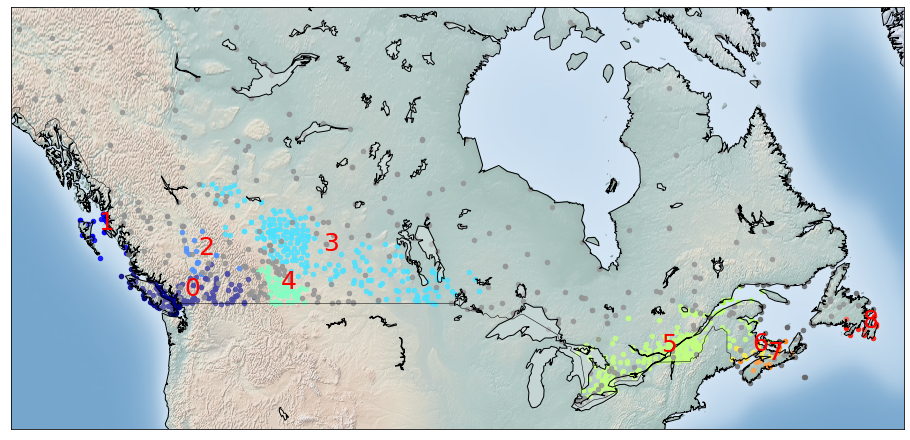

In [79]:
rcParams['figure.figsize'] = (16,12)

my_map = Basemap(projection = 'merc', resolution = 'l', area_thresh = 1000.0, llcrnrlon = llon, llcrnrlat = llat, urcrnrlon = ulon, urcrnrlat = ulat)

my_map.drawcoastlines()
my_map.drawcountries()
my_map.fillcontinents(color = 'white', alpha = 0.3)
my_map.shadedrelief()

colors = plt.get_cmap('jet')(np.linspace(0.0, 1.0, clusterNum))

for clust_number in set(labels):
    c = (([0.4,0.4,0.4]) if clust_number == -1 else colors[np.int(clust_number)])
    clust_set = pdf[pdf.Clus_Db == clust_number]
    my_map.scatter(clust_set.xm, clust_set.ym, color = c, marker = 'o', s = 20, alpha = 0.85)
    if clust_number != -1:
        cenx = np.mean(clust_set.xm)
        ceny = np.mean(clust_set.ym)
        plt.text(cenx, ceny, str(clust_number), fontsize = 25, color = 'red')
        print("Cluster " + str(clust_number)+', Avg Temp: '+str(np.mean(clust_set.Tm)))

### Clustering of Stations Based on Location and Temperature (mean, min, max)

We re-run the DBSCAN algorithm, but form clusters on a 5-dimensional data: latitude, longitude, Temperature Mean, Temperature Max, and Temperature Min

In [75]:
sklearn.utils.check_random_state(1000)
Clus_dataSet = pdf[['xm', 'ym', 'Tx', 'Tm', 'Tn']]
Clus_dataSet = np.nan_to_num(Clus_dataSet)
Clus_dataSet = StandardScaler().fit_transform(Clus_dataSet)

db = DBSCAN(eps = 0.3, min_samples = 10).fit(Clus_dataSet)
core_samples_mask = np.zeros_like(db.labels_, dtype = bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_
pdf["Clus_Db"] = labels

realClusterNum = len(set(labels)) - (1 if -1 in labels else 0)
clusterNum = len(set(labels))

pdf[["Stn_Name", "Tx", "Tm", "Clus_Db"]].head(5)

,Stn_Name,Tx,Tm,Clus_Db
0,CHEMAINUS,13.5,8.2,0
1,COWICHAN LAKE FORESTRY,15.0,7.0,0
2,LAKE COWICHAN,16.0,6.8,0
3,DUNCAN KELVIN CREEK,14.5,7.7,0
4,ESQUIMALT HARBOUR,13.1,8.8,0


Cluster 0, Avg Temp: 6.2211920529801334
Cluster 1, Avg Temp: 6.790000000000001
Cluster 2, Avg Temp: -0.49411764705882355
Cluster 3, Avg Temp: -13.877209302325586
Cluster 4, Avg Temp: -4.186274509803922
Cluster 5, Avg Temp: -16.301503759398482
Cluster 6, Avg Temp: -13.599999999999998
Cluster 7, Avg Temp: -9.753333333333334
Cluster 8, Avg Temp: -4.258333333333334


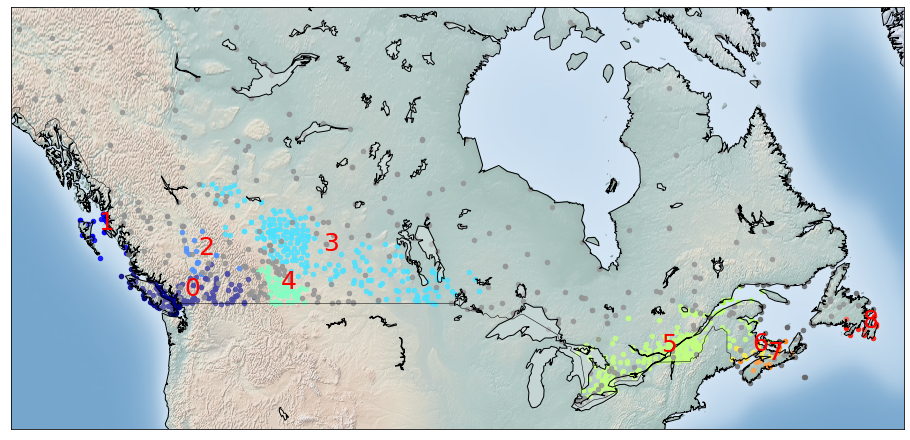

In [77]:
rcParams['figure.figsize'] = (16,12)

my_map = Basemap(projection = 'merc', resolution = 'l', area_thresh = 1000.0, llcrnrlon = llon, llcrnrlat = llat, urcrnrlon = ulon, urcrnrlat = ulat)

my_map.drawcoastlines()
my_map.drawcountries()
my_map.fillcontinents(color = 'white', alpha = 0.3)
my_map.shadedrelief()

colors = plt.get_cmap('jet')(np.linspace(0.0, 1.0, clusterNum))

for clust_number in set(labels):
    c = (([0.4, 0.4, 0.4]) if clust_number == -1 else colors[np.int(clust_number)])
    clust_set = pdf[pdf.Clus_Db == clust_number]
    my_map.scatter(clust_set.xm, clust_set.ym, color = c, marker = 'o', s = 20, alpha = 0.85)
    if clust_number != -1:
        cenx = np.mean(clust_set.xm)
        ceny = np.mean(clust_set.ym)
        plt.text(cenx, ceny, str(clust_number), fontsize = 25, color = 'red',)
        print("Cluster " +str(clust_number)+', Avg Temp: '+ str(np.mean(clust_set.Tm)))